# 04 — Modeling

**Goal:** compare a small set of models with K-fold cross-validation, pick the best one objectively, then validate it on a held-out test set and save it for the app.

Input: `data/processed/dataset_model_ready.csv`
Output: `models/eta_model.pkl` + `models/metrics.json` + feature importance chart

**The models used:** 
- **Linear Regression** — the baseline. If a tree ensemble can't beat this by much, the extra complexity isn't worth it.
- **Random Forest** — bagging, handles non-linear interactions (like our `traffic_x_distance` feature) well.
- **Gradient Boosting** (histogram-based — `HistGradientBoostingRegressor`) — boosting, usually squeezes out a bit more accuracy than Random Forest, and the histogram-based version is fast enough for 85k+ rows (the plain `GradientBoostingRegressor` is sequential and too slow at this size).


## 1. Setup

In [22]:
import pandas as pd
import numpy as np
import json, pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")

MODEL_READY_PATH = Path("../data/dataset_model_ready.csv")
MODELS_DIR = Path("../model")
FIGURES_DIR = Path("../reports/figures")
TARGET = "delivery_duration_minutes"
SEED = 42

In [2]:
df = pd.read_csv(MODEL_READY_PATH)
print(df.shape)
df.head()

(85199, 43)


,quantity,total_price,delivery_duration_minutes,restaurant_lat,restaurant_lon,customer_lat,customer_lon,driver_lat,driver_lon,delivery_distance_km,...,order_part_of_day_morning,order_part_of_day_afternoon,order_part_of_day_evening,order_part_of_day_night,city_assiut,city_cairo,city_giza,city_mansoura,city_tanta,city_zagazig
0,3,273.72,31.0,31.195082,29.921931,31.191404,29.904982,31.215658,29.910664,1.666106,...,True,False,False,False,False,False,False,False,False,False
1,3,365.82,8.0,30.605729,31.503079,30.586047,31.485820,30.580329,31.502380,2.738698,...,False,False,False,True,False,False,False,False,False,True
2,2,221.18,17.0,31.041846,31.381229,31.035773,31.380440,31.054690,31.401187,0.677498,...,False,False,False,False,False,False,False,True,False,False
3,5,355.55,8.0,31.024141,31.376104,31.026023,31.396881,31.035350,31.389315,1.994769,...,True,False,False,False,False,False,False,True,False,False
4,3,205.44,23.0,31.024140,31.387817,31.029004,31.373869,31.022573,31.380646,1.436807,...,False,True,False,False,False,False,False,True,False,False


## 2. Train/test split

We hold out 20% as a **final** test set that no model touches until the very end. Cross-validation happens only within the remaining 80% — this way the CV comparison and the final reported number are never based on the same data twice.

In [3]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (68159, 42), Test: (17040, 42)


In [24]:
X_train

,quantity,total_price,restaurant_lat,restaurant_lon,customer_lat,customer_lon,driver_lat,driver_lon,delivery_distance_km,order_hour,...,order_part_of_day_morning,order_part_of_day_afternoon,order_part_of_day_evening,order_part_of_day_night,city_assiut,city_cairo,city_giza,city_mansoura,city_tanta,city_zagazig
78706,1,111.43,30.594542,31.482181,30.583643,31.511468,30.592555,31.518310,3.057858,10,...,True,False,False,False,False,False,False,False,False,True
61680,4,546.16,27.178282,31.178114,27.163235,31.194573,27.163923,31.200219,2.332525,23,...,False,False,False,True,True,False,False,False,False,False
5855,3,294.90,30.779580,31.007914,30.774768,30.978744,30.787235,31.016999,2.842797,9,...,True,False,False,False,False,False,False,False,True,False
79193,2,102.62,30.585348,31.506651,30.569070,31.518481,30.605430,31.491835,2.131779,5,...,False,False,False,False,False,False,False,False,False,True
58708,3,284.31,30.051195,31.254676,30.031178,31.254205,30.038597,31.231554,2.219412,7,...,True,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,2,138.66,27.195365,31.199833,27.167798,31.176374,27.164747,31.189569,3.838586,2,...,False,False,False,False,True,False,False,False,False,False
54886,5,462.65,31.054908,31.379654,31.039137,31.373807,31.023958,31.400258,1.835476,21,...,False,False,False,True,False,False,False,True,False,False
76820,3,165.00,30.031129,31.216575,30.025117,31.235998,30.054198,31.227001,1.988506,7,...,True,False,False,False,False,True,False,False,False,False
860,3,420.15,30.779264,31.004863,30.801333,30.990662,30.794309,30.985435,2.798925,21,...,False,False,False,True,False,False,False,False,True,False


## 3. Define candidate models

Linear Regression gets a `StandardScaler` in front of it (it's sensitive to feature scale — a distance in km and a price in EGP shouldn't be treated as the same magnitude). The tree-based models don't need scaling, so they skip it — wrapping everything in a `Pipeline` keeps this consistent and leak-free (the scaler is fit fresh inside each CV fold, not once on the whole training set).

In [4]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1
    ),
    "Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=300, max_depth=6, learning_rate=0.05, random_state=SEED
    ),
}

## 4. 5-fold cross-validation on the training set

For each model, we get 5 R² and 5 MAE scores (one per fold) instead of a single number — this tells us not just how good a model is on average, but how *consistent* it is. A model with a high mean but wildly varying fold scores is less trustworthy than one that's stable.

In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train, cv=kf,
        scoring={"r2": "r2", "mae": "neg_mean_absolute_error"},
        n_jobs=-1,
    )
    cv_results[name] = {
        "r2_scores": scores["test_r2"],
        "mae_scores": -scores["test_mae"],
    }
    print(f"{name}:")
    print(f"  R^2 score = {scores['test_r2'].mean():.4f}  (+/- {scores['test_r2'].std():.4f})")
    print(f"  MAE  = {-scores['test_mae'].mean():.4f}  (+/- {scores['test_mae'].std():.4f})")

Linear Regression:
  R^2 score = 0.7651  (+/- 0.0019)
  MAE  = 3.1816  (+/- 0.0221)
Random Forest:
  R^2 score = 0.7983  (+/- 0.0017)
  MAE  = 2.9362  (+/- 0.0210)
Gradient Boosting:
  R^2 score = 0.8105  (+/- 0.0019)
  MAE  = 2.8431  (+/- 0.0209)


## 5. Compare models visually

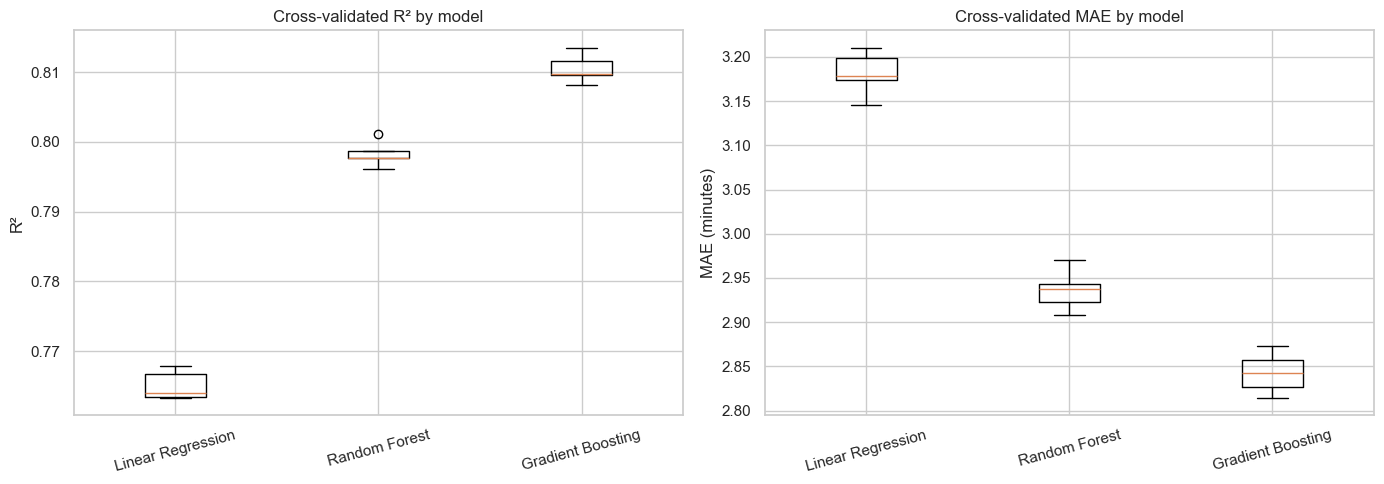

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

r2_data = [cv_results[name]["r2_scores"] for name in models]
mae_data = [cv_results[name]["mae_scores"] for name in models]

axes[0].boxplot(r2_data, tick_labels=models.keys())
axes[0].set_title("Cross-validated R² by model")
axes[0].set_ylabel("R²")
axes[0].tick_params(axis="x", rotation=15)

axes[1].boxplot(mae_data, tick_labels=models.keys())
axes[1].set_title("Cross-validated MAE by model")
axes[1].set_ylabel("MAE (minutes)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
#plt.savefig(FIGURES_DIR / "model_comparison_cv.png", dpi=150)
plt.show()

## 6. Pick the best model

We select on **mean CV R²** — highest average performance across folds.

In [8]:
best_name = max(cv_results, key=lambda n: cv_results[n]["r2_scores"].mean())
print(f"Best model by CV R^2: {best_name}")

best_model = models[best_name]

Best model by CV R^2: Gradient Boosting


## 7. Retrain on full training set, evaluate on held-out test set

This is the number that actually matters — performance on data the model (and the model-*selection* process) has never seen at all.

In [10]:
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

final_metrics = {
    "model": best_name,
    "r2": r2_score(y_test, preds),
    "mae": mean_absolute_error(y_test, preds),
    "rmse": mean_squared_error(y_test, preds) ** 0.5,
    "n_train": len(X_train),
    "n_test": len(X_test),
    "cv_r2_mean": cv_results[best_name]["r2_scores"].mean(),
    "cv_r2_std": cv_results[best_name]["r2_scores"].std(),
}
final_metrics

{'model': 'Gradient Boosting',
 'r2': 0.8138699627263769,
 'mae': 2.8274821814084303,
 'rmse': 3.566351408990682,
 'n_train': 68159,
 'n_test': 17040,
 'cv_r2_mean': np.float64(0.8104972034306209),
 'cv_r2_std': np.float64(0.001853111392891513)}

## 8. Predicted vs actual

A well-fit model's points should cluster tightly around the diagonal. Systematic bias (points consistently above or below the line) would show up here even if R² looks fine.

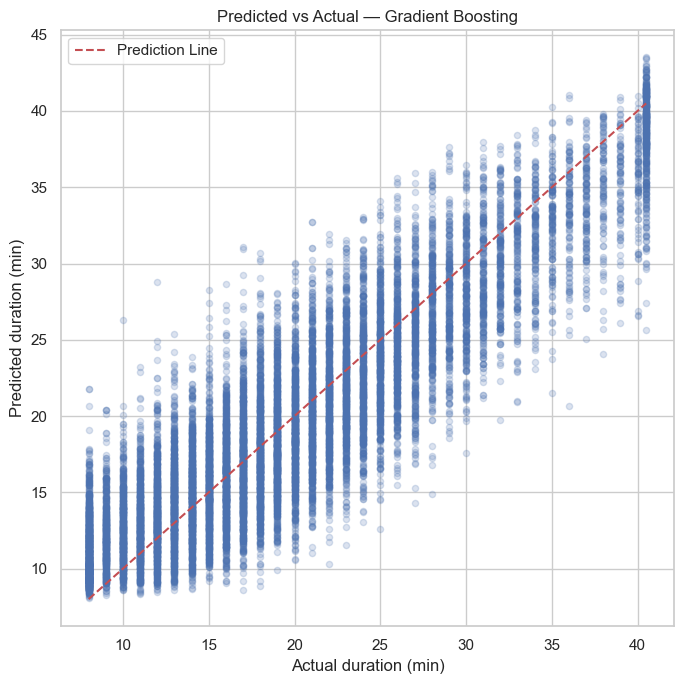

In [19]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds, alpha=0.20, s=20)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "r--", label="Prediction Line")
plt.xlabel("Actual duration (min)")
plt.ylabel("Predicted duration (min)")
plt.title(f"Predicted vs Actual — {best_name}")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "predicted_vs_actual.png", dpi=150)
plt.show()

## 9. Feature importance

`RandomForestRegressor` exposes `.feature_importances_` directly, but
`HistGradientBoostingRegressor` doesn't — it's a sklearn limitation, not
something wrong with the model. **Permutation importance** works for any
model: it shuffles one feature's values at a time and measures how much
the model's performance drops — a bigger drop means the model relied on
that feature more heavily.

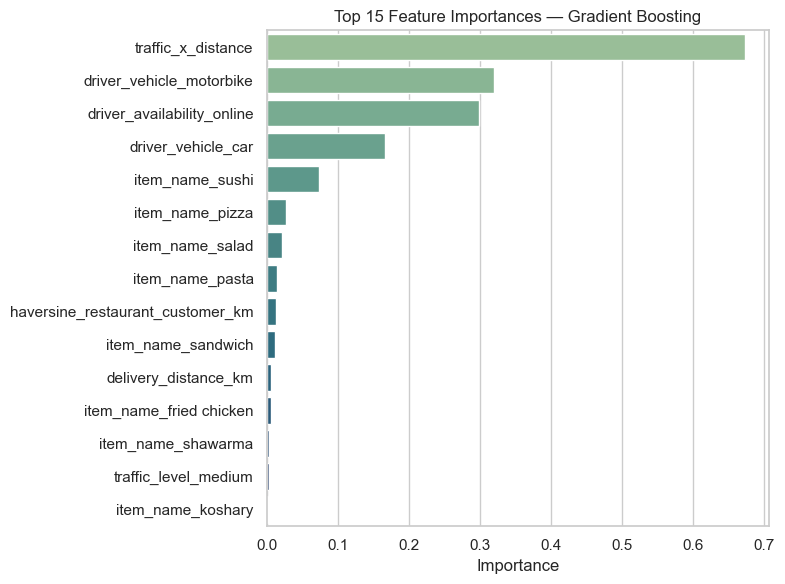

In [20]:
from sklearn.inspection import permutation_importance

if hasattr(best_model, "feature_importances_"):
    importances = sorted(zip(X.columns, best_model.feature_importances_), key=lambda x: -x[1])
else:
    perm = permutation_importance(best_model, X_test, y_test, n_repeats=5, random_state=SEED, n_jobs=-1)
    importances = sorted(zip(X.columns, perm.importances_mean), key=lambda x: -x[1])

top_n = importances[:15]
plt.figure(figsize=(8, 6))
sns.barplot(x=[v for _, v in top_n], y=[k for k, _ in top_n],
            hue=[k for k, _ in top_n], palette="crest", legend=False)
plt.title(f"Top 15 Feature Importances — {best_name}")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=150)
plt.show()

## 10. Save the model

In [23]:
with open(MODELS_DIR / "eta_model.pkl", "wb") as f:
    pickle.dump({"model": best_model, "feature_columns": X.columns.tolist(), "model_name": best_name}, f)

with open(MODELS_DIR / "metrics.json", "w") as f:
    json.dump(final_metrics, f, indent=2)

print(f"Saved model ({best_name}) -> {MODELS_DIR / 'eta_model.pkl'}")
print(f"Saved metrics -> {MODELS_DIR / 'metrics.json'}")
print(f"\nFinal test R^2: {final_metrics['r2']:.4f}, MAE: {final_metrics['mae']:.2f} min")

Saved model (Gradient Boosting) -> ..\model\eta_model.pkl
Saved metrics -> ..\model\metrics.json

Final test R^2: 0.8139, MAE: 2.83 min
